# 📘 Домашнє завдання №20. Курсовий проєкт

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW20_Course_Project

Dataset: https://www.kaggle.com/datasets/rohitudageri/credit-card-details  
Тип задачі: Binary Classification  
Мета: побудувати повний ML pipeline від raw data до explainable model

---

# Бізнес-контекст

Вам потрібно побудувати модель, яка передбачає:
чи буде заявка на кредитну картку схвалена або відхилена

Це класична задача credit scoring, де важливі:
- ризик дефолту
- стабільність доходів
- кредитна історія
- демографічні фактори

---

# Етап 1 — Data Understanding & EDA

Що потрібно зробити:
- перевірити розподіл таргету (imbalance)
- описати кожну змінну
- знайти категоріальні/числові фічі
- перевірити пропуски та аномалії

Підказки:
- income може бути skewed (log-transform корисний)
- age можуть бути outliers
- credit history length може містити нулі або пропуски
- категоріальні змінні можуть включати education, marital status, occupation
- можливий сильний imbalance target

Обов’язково зробити:
- histograms для числових фіч
- bar plots для категоріальних фіч
- correlation heatmap
- target distribution plot

---

# Етап 2 — Data Cleaning

Що потрібно:
- обробити missing values
- привести типи змінних
- обробити duplicates
- перевірити inconsistent categories

Підказки:
- missing income краще заповнювати median або grouped imputation
- категорії можуть містити unknown, other, ?
- перевірити аномалії:
  - negative income
  - age < 18

---

# Етап 3 — Feature Engineering

Що потрібно створити:

Risk-based features:
- income per age
- credit history ratio
- debt-to-income proxy (якщо є борги)

Binning features:
- age groups (18–25, 25–40, 40–60, 60+)
- income quartiles

Interaction features:
- income × employment status
- credit history × age

Binary flags:
- high income flag
- young applicant flag
- no credit history flag

Порада:
не створювати надто багато фіч, краще менше, але якісних

---

# Етап 4 — Feature Selection

Використати мінімум 2 методи:
- correlation analysis
- mutual information
- tree-based importance (Random Forest або XGBoost)
- permutation importance

Мета:
- прибрати шумові фічі
- залишити стабільні предиктори
- пояснити вибір фіч

---

# Етап 5 — Model Selection (Cross-Validation)

Порівняти 3 моделі (наприклад):
- Logistic Regression
- Random Forest
- XGBoost

Вимоги:
- StratifiedKFold (5 folds)
- ROC-AUC як основна метрика
- порівняти mean і std

Порада:
- перевірити imbalance
- оцінити стабільність Logistic Regression
- перевірити реальний gain від XGBoost

---

# Етап 6 — Hyperparameter Tuning

Обов’язково:
- XGBoost tuning (Optuna або GridSearch)
- або Logistic Regression GridSearch

Параметри XGBoost:
- max_depth
- learning_rate
- n_estimators
- subsample
- colsample_bytree
- reg_lambda
- reg_alpha

Порада:
не тюнити всі параметри одночасно, робити поетапно

---

# Етап 7 — Evaluation

Обов’язкові метрики:
- ROC-AUC
- Precision
- Recall
- F1-score
- Confusion Matrix

Важливо:
- не використовувати лише accuracy
- аналізувати recall для позитивного класу

---

# Етап 8 — Explainability

Використати мінімум 2 методи:
- Logistic Regression coefficients
- Feature Importance
- RuleFit
- SHAP для XGBoost

Пояснити:
- які фактори впливають на approval
- як змінюється ризик
- локальні пояснення для окремих прикладів

---

# Етап 9 — Error Analysis

Проаналізувати:
- false positives
- false negatives

Перевірити:
- чи є закономірності в помилках
- чи пов’язані вони з income, age, credit history

---

# Очікуваний результат

Ви повинні отримати:
- чистий датасет
- engineered features
- порівняння моделей через CV
- tuned фінальну модель
- explainability аналіз
- бізнес-інсайти

---

# Критерії оцінювання

EDA + cleaning 20%
Feature engineering 20%
Model comparison 20%
Tuning 15%
Explainability 15%
Insights + conclusions 10%

---

# Фінальний меседж

Мета роботи — не побудувати найкращу модель, а навчитися пояснювати, чому модель приймає рішення.

In [1]:
# # Silent installation or update
#
# # Clean cache
# !python3 -m pip cache purge -q
#
# # Force updating
# package_update = [
#     "pip",
#     "scikit-learn",
#     "pandas",
# ]
#
# for package_name in package_update:
#     !bash -c "python3 -m pip install -U '{package_name}' -q"
#
# # Install missing packages
# package_array = [
#     "jinja2",
#     "ipywidgets",
#     "nbformat",
#     "kagglehub[pandas-datasets]",
#     "numpy",
#     "matplotlib",
#     "scipy",
#     "statsmodels",
#     "joblib",
#     "seaborn",
# ]
#
# for package_name in package_array:
#     !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [2]:
# # Synchronization with remote source
#
# import shutil
# from pathlib import Path
#
# # Input data
hm_version = 20
#
# # Solution
# git_project_url = f"https://github.com/BogdanPinchuk/DataScience-PBY_HW{hm_version}_Course_Project.git"
# main_file_name = f"Bohdan_Pinchuk_DS_HW{hm_version}.ipynb"
#
# # upload all files
# current_path = !pwd
# current_path = current_path[0]
# parent_path = !dirname "$current_path"
# parent_path = parent_path[0]
# temp_path = f"{parent_path}/temp"
#
# # Clone data
# !rm -rf "$temp_path"
# !git clone "$git_project_url" "$temp_path"
#
# source = Path(temp_path)
# destination = Path(current_path)
# exclude = {main_file_name, ".git", ".idea"}
#
# for item in source.iterdir():
#     if item.name in exclude:
#         continue
#
#     target = destination / item.name
#     if item.is_dir():
#         shutil.copytree(item, target, dirs_exist_ok=True)
#     else:
#         shutil.copy2(item, target)
#
# # Clean temp folder
# !rm -rf "$temp_path"

# ✳️ Підготовка датасетів

In [3]:
# Downloading data

import gc
import pandas as pd
import apps.main as mn

# Input data
target_value = "label"
update_db = False
db_file_name = f"resources/store_hw{hm_version}.db"

# Solution
pd.options.display.float_format = "{:g}".format
credit_card_details_dataset = mn.download_and_extract_from_kagglehub("rohitudageri/credit-card-details",
                                                                     "Credit_card.csv",
                                                                     db_file_name,
                                                                     update_db=update_db)

credit_card_labels_dataset = mn.download_and_extract_from_kagglehub("rohitudageri/credit-card-details",
                                                                    "Credit_card_label.csv",
                                                                    db_file_name,
                                                                    ds_name="credit_card_labels",
                                                                    update_db=update_db)

# робимо заміну для кращого сприйняття, 0 - false, 1 - true по схваленні заявки
credit_card_labels_dataset[target_value] = credit_card_labels_dataset[target_value].map({0: 1, 1: 0})

# Merge
credit_card_dataset = (
    pd.merge(credit_card_details_dataset, credit_card_labels_dataset, on="Ind_ID", how="outer"))  # type: ignore

del credit_card_details_dataset, credit_card_labels_dataset

# Print result
# display(credit_card_dataset)

# Clean
_ = gc.collect()

# ✅ Рішення: Етап 1 — Data Understanding & EDA

Що потрібно зробити:
- перевірити розподіл таргету (imbalance)
- описати кожну змінну
- знайти категоріальні/числові фічі
- перевірити пропуски та аномалії

Підказки:
- income може бути skewed (log-transform корисний)
- age можуть бути outliers
- credit history length може містити нулі або пропуски
- категоріальні змінні можуть включати education, marital status, occupation
- можливий сильний imbalance target

Обов’язково зробити:
- histograms для числових фіч
- bar plots для категоріальних фіч
- correlation heatmap
- target distribution plot

In [4]:
# Data description

import numpy as np
import pandas as pd
import apps.reporter as rpt
from IPython.display import display
from IPython.core.display import Markdown

# Input data
n_first_rows = 5
balans_level = 0.1
ds_name = "Credit card Details"

# Solution
data_set = credit_card_dataset

n_columns = data_set.columns.size
n_rows = data_set.index.size

types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

col_num_type = data_set.select_dtypes(include=np.number)
col_cat_type = data_set.select_dtypes(exclude=np.number)

empty_val_by_col = data_set.isnull().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = rpt.Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.columns.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')

sorted_target_values_count = data_set[target_value].value_counts().tolist()
max_contrast = mn.contrast(min(sorted_target_values_count), max(sorted_target_values_count))

rp1 = rpt.Reporter()
rp1.add_item("Рівень датасету,\nпри якому він буде вважатися збалансованим", f"{balans_level:.2%}")
rp1.add_item("Датасет збалансований", 'так' if max_contrast <= balans_level else 'ні')
rp1.add_item("Максимальна відмінність між класами", f"{max_contrast:.2%}")

# Print results
display(Markdown(f"### Аналіз даних"))
display(data_set.head(n_first_rows).
        style.format("{:g}", subset=col_num_type.columns).
        set_caption(f"Перші {n_first_rows} рядків датасету"))

rp.print_pd_report("Параметри таблиці")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))
display(types_df.style.set_caption("Типи даних"))

display(col_num_type.describe().T.style.format("{:g}").set_caption("Статистика числових змінних"))

display(col_cat_type.describe().T.style.set_caption("Статистика для категоріальних змінних"))

for col_name in col_cat_type:
    display(pd.concat([
        col_cat_type[col_name].value_counts(),
        col_cat_type[col_name].value_counts(normalize=True)
    ], axis=1).style.set_caption(f"Категорія: \"{col_name}\""))

display(pd.concat([
    data_set[target_value].value_counts(),
    data_set[target_value].value_counts(normalize=True),
], axis=1).style.set_caption("Цільова змінна"))

rp1.print_pd_report("Збалансованість датасету за цільовою змінною")

### Аналіз даних

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5.00883e+06,M,Y,Y,0,180000,Pensioner,Higher education,Married,House / apartment,-18772,365243,1,0,0,0,nan,2,0
1,5.00886e+06,F,Y,Y,2,135000,Working,Secondary / secondary special,Married,House / apartment,-15761,-3173,1,0,0,0,Laborers,4,1
2,5.00889e+06,F,N,Y,0,247500,Commercial associate,Higher education,Separated,Rented apartment,-17016,-1347,1,0,0,0,Core staff,1,1
3,5.009e+06,M,Y,Y,0,157500,Working,Secondary / secondary special,Married,House / apartment,-9927,-828,1,0,0,0,Drivers,2,1
4,5.00902e+06,F,N,Y,2,216000,State servant,Higher education,Married,House / apartment,-15444,-3112,1,0,0,1,nan,4,1


Attribute,Result
Кількість рядків,1548
Кількість стовпців,19
Кількість числових ознак,11
Кількість категоріальних ознак,12384
Пропущені значення,є


,count
Ind_ID,0
GENDER,7
Car_Owner,0
Propert_Owner,0
CHILDREN,0
Annual_income,23
Type_Income,0
EDUCATION,0
Marital_status,0
Housing_type,0


,Types
Ind_ID,int64
GENDER,str
Car_Owner,str
Propert_Owner,str
CHILDREN,int64
Annual_income,float64
Type_Income,str
EDUCATION,str
Marital_status,str
Housing_type,str


...

,count,proportion
Marital_status,,
Married,1049,0.677649
Single / not married,227,0.146641
Civil marriage,101,0.065245
Separated,96,0.062016
Widow,75,0.048450


,count,proportion
Housing_type,,
House / apartment,1380,0.891473
With parents,80,0.051680
Municipal apartment,53,0.034238
Rented apartment,21,0.013566
Office apartment,9,0.005814
Co-op apartment,5,0.003230


,count,proportion
Type_Occupation,,
Laborers,268,0.252830
Core staff,174,0.164151
Managers,136,0.128302
Sales staff,122,0.115094
Drivers,86,0.081132
High skill tech staff,65,0.061321
Medicine staff,50,0.047170
Accountants,44,0.041509
Security staff,25,0.023585


,count,proportion
label,,
1,1373,0.886951
0,175,0.113049


Attribute,Result
"Рівень датасету, при якому він буде вважатися збалансованим",10.00%
Датасет збалансований,ні
Максимальна відмінність між класами,77.39%


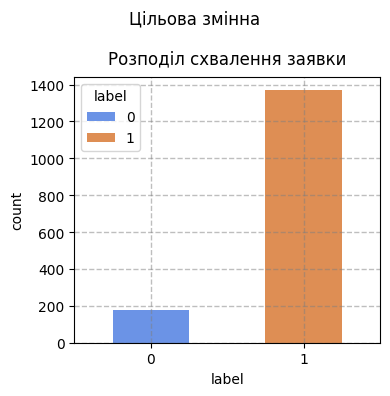

In [6]:
# Graphic results

import seaborn as sns
import matplotlib.pyplot as plt

# Input data
data_set = credit_card_dataset

# Solution
_, ax = plt.subplots(figsize=(4, 4))

sns.countplot(data=data_set, ax=ax, x=target_value, hue=target_value, width=0.5)

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.set_title("Розподіл схвалення заявки", pad=10, loc='center', color='black')

plt.suptitle("Цільова змінна")

plt.tight_layout()
plt.show()